Monet2 trials: 40
Neural data shape: (376, 7665)
Video data shape: (376, 72, 128, 1)
Train: 282 | Test: 94
Correlation: -0.0032 +/- 0.0551


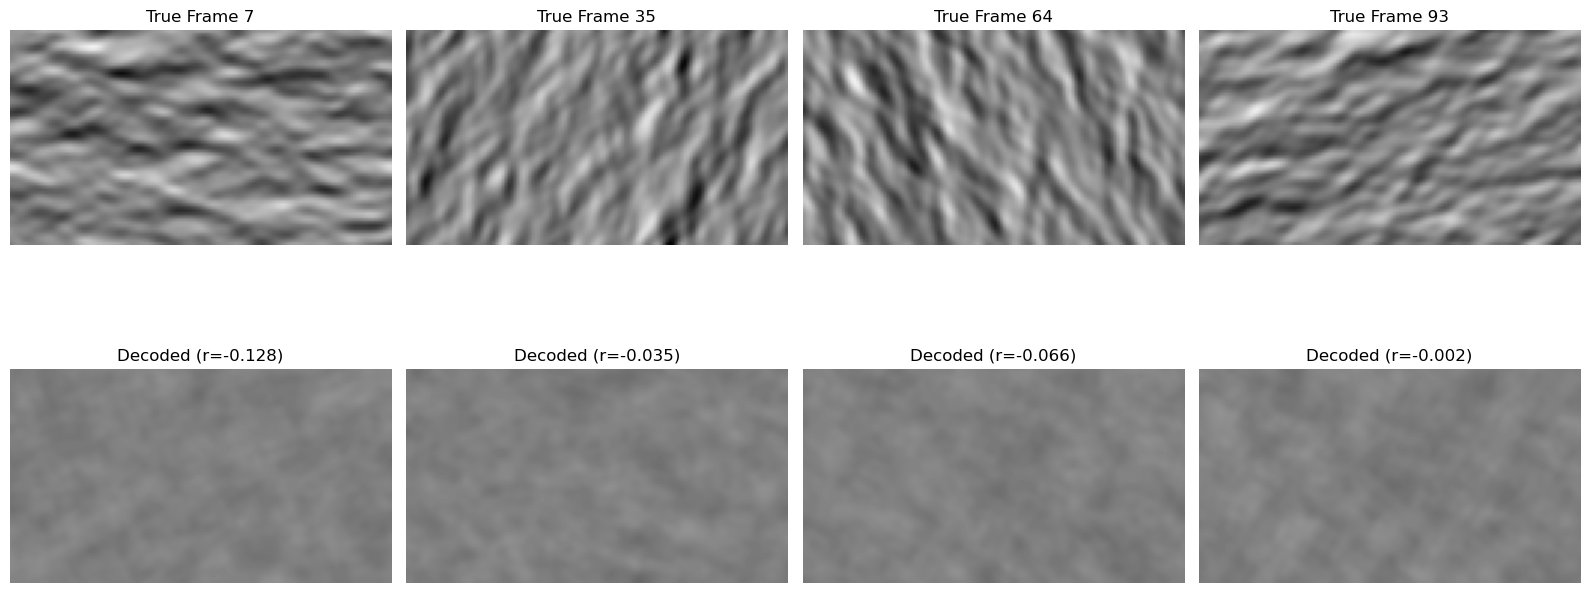

In [4]:
"""
Monet Stimulus Neural Decoder
Decodes Monet2 stimuli
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import gaussian_filter1d
import remfile
import h5py
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient


class KNNDecoder:
    def __init__(self, n_neighbors=30, temporal_window=8):
        self.n_neighbors = n_neighbors
        self.temporal_window = temporal_window
        self.knn = None
        self.scaler = None
        self.train_frames = None
        
    def _create_temporal_features(self, neural_data):
        features = []
        valid_indices = []
        
        for i in range(self.temporal_window-1, len(neural_data)):
            window = neural_data[i-self.temporal_window+1:i+1]
            features.append(window.flatten())
            valid_indices.append(i)
        
        return np.array(features), np.array(valid_indices)
        
    def fit(self, neural_data, frames):
        neural_features, valid_indices = self._create_temporal_features(neural_data)
        self.train_frames = frames[valid_indices]
        
        self.scaler = StandardScaler()
        neural_features = self.scaler.fit_transform(neural_features)
        
        self.knn = NearestNeighbors(
            n_neighbors=min(self.n_neighbors, len(neural_features)),
            metric='euclidean',
            algorithm='auto'
        )
        self.knn.fit(neural_features)
        
    def predict(self, neural_data):
        neural_features, valid_indices = self._create_temporal_features(neural_data)
        neural_features = self.scaler.transform(neural_features)
        
        distances, indices = self.knn.kneighbors(neural_features)
        
        predictions = []
        for i in range(len(neural_features)):
            neighbor_frames = self.train_frames[indices[i]]
            weights = 1.0 / (distances[i] + 1e-10)
            weights = weights / weights.sum()
            pred = np.average(neighbor_frames, axis=0, weights=weights)
            predictions.append(pred)
        
        return np.array(predictions), valid_indices
    
    def evaluate(self, neural_data, true_frames):
        predictions, valid_indices = self.predict(neural_data)
        true_frames_valid = true_frames[valid_indices]
        
        correlations = []
        for i in range(len(predictions)):
            r = np.corrcoef(true_frames_valid[i].flatten(), predictions[i].flatten())[0,1]
            if not np.isnan(r):
                correlations.append(r)
        
        return {
            'correlation': np.mean(correlations),
            'std': np.std(correlations),
            'predictions': predictions,
            'valid_indices': valid_indices
        }


def load_monet_data(max_samples=5000):
    """Load data for Monet2 stimulus."""
    
    with DandiAPIClient() as client:
        dandiset = client.get_dandiset("000402", "draft")
        asset = next(a for a in dandiset.get_assets() if a.path.endswith(".nwb"))
    
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)
    rf = remfile.File(s3_url)
    h5_file = h5py.File(rf, "r")
    io = NWBHDF5IO(file=h5_file, load_namespaces=True)
    nwb = io.read()
    
    # Get Monet2 intervals
    monet_intervals = nwb.intervals['Monet2']
    start_times = np.array(monet_intervals.start_time[:])
    stop_times = np.array(monet_intervals.stop_time[:])
    
    print(f"Monet2 trials: {len(start_times)}")
    
    # Load all 8 planes
    all_neural_data = []
    all_timestamps = None
    
    fluorescence = nwb.processing['ophys'].data_interfaces['Fluorescence']
    
    for plane_idx in range(8):
        roi_series_name = f'RoiResponseSeries{plane_idx}'
        
        if roi_series_name not in fluorescence.roi_response_series:
            continue
            
        roi_series = fluorescence.roi_response_series[roi_series_name]
        neural_data = np.array(roi_series.data[:max_samples])
        timestamps = np.array(roi_series.timestamps[:max_samples])
        
        neural_data = gaussian_filter1d(neural_data, 1.5, axis=0)
        all_neural_data.append(neural_data)
        
        if all_timestamps is None:
            all_timestamps = timestamps
    
    combined_neural = np.concatenate(all_neural_data, axis=1)
    
    # Filter for Monet2 stimulus
    monet_mask = np.zeros(len(all_timestamps), dtype=bool)
    for start, stop in zip(start_times, stop_times):
        monet_mask |= (all_timestamps >= start) & (all_timestamps <= stop)
    
    combined_neural = combined_neural[monet_mask]
    filtered_timestamps = all_timestamps[monet_mask]
    
    # Load video
    video_stim = nwb.acquisition['Video: stimulus_17797_4_7_v4']
    video_timestamps = np.array(video_stim.timestamps[:])
    
    frame_indices = np.searchsorted(video_timestamps, filtered_timestamps)
    frame_indices = np.minimum(frame_indices, len(video_timestamps)-1)
    
    video_data = []
    for idx in frame_indices:
        frame = video_stim.data[idx]
        frame = frame[::2, ::2, :]
        frame_gray = np.mean(frame, axis=2, keepdims=True)
        video_data.append(frame_gray)
    
    video_data = np.array(video_data)
    
    print(f"Neural data shape: {combined_neural.shape}")
    print(f"Video data shape: {video_data.shape}")
    
    return combined_neural, video_data


def run_monet_experiment():
    """Run decoder on Monet stimulus."""
    
    neural_data, video_data = load_monet_data(max_samples=5000)
    
    # Split train/test
    n_train = int(0.75 * len(neural_data))
    train_neural = neural_data[:n_train]
    train_video = video_data[:n_train]
    test_neural = neural_data[n_train:]
    test_video = video_data[n_train:]
    
    print(f"Train: {len(train_neural)} | Test: {len(test_neural)}")
    
    # Train
    decoder = KNNDecoder(n_neighbors=30, temporal_window=8)
    decoder.fit(train_neural, train_video)
    
    # Evaluate
    results = decoder.evaluate(test_neural, test_video)
    
    print(f"Correlation: {results['correlation']:.4f} +/- {results['std']:.4f}")
    
    return decoder, results, test_neural, test_video


def visualize_results(results, test_video):
    """Plot results."""
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    predictions = results['predictions']
    valid_indices = results['valid_indices']
    
    # Show 4 examples
    n_examples = 4
    example_idx = np.linspace(0, len(valid_indices)-1, n_examples, dtype=int)
    
    for i, idx in enumerate(example_idx):
        true = test_video[valid_indices[idx]]
        pred = predictions[idx]
        r = np.corrcoef(true.flatten(), pred.flatten())[0,1]
        
        axes[0, i].imshow(true.squeeze(), cmap='gray', vmin=0, vmax=255)
        axes[0, i].set_title(f'True Frame {valid_indices[idx]}')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(pred.squeeze(), cmap='gray', vmin=0, vmax=255)
        axes[1, i].set_title(f'Decoded (r={r:.3f})')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.savefig('monet_results.png', dpi=150, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    decoder, results, test_neural, test_video = run_monet_experiment()
    visualize_results(results, test_video)